In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from collections import defaultdict
from typing import Union, Sequence, Tuple, List, Optional
from itertools import chain

In [2]:


def all_leaf_dirs_have_mk(
    root_dir: Union[str, Path],
    filename: str = "mk.csv",
    *,
    return_missing: bool = False
) -> Union[bool, Tuple[bool, Sequence[Path]]]:
    """
    Recursively ensure that every *leaf* directory (one with no sub‑directories)
    beneath *root_dir* contains ``filename``.

    Parameters
    ----------
    root_dir : str | pathlib.Path
        Directory at which to start the walk.
    filename : str, default "mk.csv"
        Required file name (case‑sensitive).
    return_missing : bool, default False
        If True, return a tuple ``(ok, missing)`` where *missing* lists the
        offending leaf directories.

    Returns
    -------
    bool
        True  – every leaf directory contained *filename*
        False – at least one leaf directory lacked *filename*
    tuple[bool, list[pathlib.Path]]  (if *return_missing* is True)
    """
    root = Path(root_dir).expanduser().resolve()
    if not root.is_dir():
        raise NotADirectoryError(f"{root} is not a directory")

    missing: List[Path] = []

    # Examine *only* directories, starting with root, then all contents.
    for current_dir in chain([root], root.rglob("*")):
        if not current_dir.is_dir():
            continue

        # List immediate sub‑directories of the current directory
        subdirs = [d for d in current_dir.iterdir() if d.is_dir()]

        # A leaf directory has no sub‑directories
        if not subdirs and not (current_dir / filename).is_file():
            missing.append(current_dir)

    ok = len(missing) == 0
    return (ok, missing) if return_missing else ok

test = all_leaf_dirs_have_mk("./checkpoints_exp", return_missing=True)
print(test)

(True, [])


In [3]:
def get_results_comb_bench(folder_path: str):
    edata_df = pd.read_csv(os.path.join(folder_path, "edata.csv"))
    vdata_df = pd.read_csv(os.path.join(folder_path, "vdata.csv"))
    rdata_df = pd.read_csv(os.path.join(folder_path, "rdata.csv"))
    mk_df = pd.read_csv(os.path.join(folder_path, "mk.csv"))
    sd1_df = pd.read_csv(os.path.join(folder_path, "sd1.csv"))
    edata_gap_greedy = edata_df["gap_det_offline"].mean()
    edata_gap_samp = edata_df["gap_stoch_offline"].mean()
    vdata_gap_greedy = vdata_df["gap_det_offline"].mean()
    vdata_gap_samp = vdata_df["gap_stoch_offline"].mean()
    mk_gap_greedy = mk_df["gap_det_offline"].mean()
    mk_gap_samp = mk_df["gap_stoch_offline"].mean()
    sd1_gap_greedy = sd1_df["gap_det_offline"].mean()
    sd1_gap_samp = sd1_df["gap_stoch_offline"].mean()
    rdata_gap_greedy = rdata_df["gap_det_offline"].mean()
    rdata_gap_samp = rdata_df["gap_stoch_offline"].mean()
    bench_gap_greedy = (edata_gap_greedy + vdata_gap_greedy + mk_gap_greedy + rdata_gap_greedy) / 4
    bench_gap_samp = (edata_gap_samp + vdata_gap_samp + mk_gap_samp + rdata_gap_samp) / 4
    return sd1_gap_greedy, sd1_gap_samp, bench_gap_greedy, bench_gap_samp

def group_folders_by_prefix(parent: str | Path) -> dict[str, list[Path]]:
    """
    Traverse *parent* and group every immediate sub‑directory by the prefix
    that appears before the first hyphen in its name.

    Parameters
    ----------
    parent : str | Path
        Path to the directory whose immediate sub‑folders will be examined.

    Returns
    -------
    dict[str, list[pathlib.Path]]
        Mapping from discovered prefix to the corresponding folders.
    """
    parent = Path(parent).expanduser().resolve()
    if not parent.is_dir():
        raise NotADirectoryError(f"{parent} is not a directory.")

    groups: dict[str, list[Path]] = defaultdict(list)

    for entry in parent.iterdir():
        if entry.is_dir():
            prefix, *_ = entry.name.split("-", 1)
            groups[prefix].append(entry)

    # (Optional) sort the lists for deterministic output
    for folder_list in groups.values():
        folder_list.sort()

    return dict(groups)

def collect_results(path: str | Path, rename_dict_keys: Optional[dict] = None, save_path: Optional[str] = None) -> dict[str, dict[str, pd.DataFrame]]:
    """
    Collect results from all folders in the given path.

    Parameters
    ----------
    path : str | Path
        Path to the directory containing the folders.

    Returns
    -------
    dict[str, dict[str, pd.DataFrame]]
        Dictionary with folder names as keys and dictionaries of DataFrames as values.
    """
    path = os.path.join(path, "CDQAC", "sd1")
    path = Path(path).expanduser().resolve()

    if not path.is_dir():
        raise NotADirectoryError(f"{path} is not a directory.")

    df_results = {
        "exp_name": [],
        "gap_gen_greedy": [],
        "gap_gen_greedy_std": [],
        "gap_gen_samp": [],
        "gap_gen_samp_std": [],
        "gap_bench_greedy": [],
        "gap_bench_greedy_std": [],
        "gap_bench_samp": [],
        "gap_bench_samp_std": [],
    }
    folder_dict = group_folders_by_prefix(path)
    if rename_dict_keys is not None:
        folder_dict = {rename_dict_keys.get(k, k): v for k, v in folder_dict.items()}
    for exp_name, folders in folder_dict.items():
        # print(exp_name)
        gap_gen_greedy = []
        gap_gen_samp = []
        gap_bench_greedy = []
        gap_bench_samp = []
        assert len(folders) == 4, f"Expected 4 folders for {exp_name}, but found {len(folders)}"
        for folder in folders:
            # print(folder)
            gap_gen_g, gap_gen_s, gap_bench_g, gap_bench_s = get_results_comb_bench(folder)
            gap_gen_greedy.append(gap_gen_g)
            gap_gen_samp.append(gap_gen_s)
            gap_bench_greedy.append(gap_bench_g)
            gap_bench_samp.append(gap_bench_s)
        gap_gen_greedy_mean = np.mean(gap_gen_greedy)
        gap_gen_greedy_std = np.std(gap_gen_greedy)
        gap_gen_samp_mean = np.mean(gap_gen_samp)
        gap_gen_samp_std = np.std(gap_gen_samp)
        gap_bench_greedy_mean = np.mean(gap_bench_greedy)
        gap_bench_greedy_std = np.std(gap_bench_greedy)
        gap_bench_samp_mean = np.mean(gap_bench_samp)
        gap_bench_samp_std = np.std(gap_bench_samp)
        df_results["exp_name"].append(int(exp_name))
        df_results["gap_gen_greedy"].append(gap_gen_greedy_mean)
        df_results["gap_gen_greedy_std"].append(gap_gen_greedy_std)
        df_results["gap_gen_samp"].append(gap_gen_samp_mean)
        df_results["gap_gen_samp_std"].append(gap_gen_samp_std)
        df_results["gap_bench_greedy"].append(gap_bench_greedy_mean)
        df_results["gap_bench_greedy_std"].append(gap_bench_greedy_std)
        df_results["gap_bench_samp"].append(gap_bench_samp_mean)
        df_results["gap_bench_samp_std"].append(gap_bench_samp_std)
    df_results = pd.DataFrame(df_results)
    # df_results[]
    df_results = df_results.sort_values(by=['exp_name'], ascending=True)
    # print(df_results)
    if save_path is not None:
        df_results.to_csv(save_path, index=False)
        # return

collect_results("./checkpoints_exp/size_dataset_exp_10_5", rename_dict_keys={"random": "500"}, save_path="./results_dataset_size/instance_size/10_5.csv")
collect_results("./checkpoints_exp/size_dataset_exp_15_10", rename_dict_keys={"random": "500"}, save_path="./results_dataset_size/instance_size/15_10.csv")

collect_results("./checkpoints_exp/size_dataset_exp_20_10", rename_dict_keys={"random": "500"}, save_path="./results_dataset_size/instance_size/20_10.csv")

collect_results("./checkpoints_exp/size_random_exp_10_5", rename_dict_keys={"random": "100"}, save_path="./results_dataset_size/random_size/10_5.csv")
collect_results("./checkpoints_exp/size_random_exp_15_10", rename_dict_keys={"random": "100"}, save_path="./results_dataset_size/random_size/15_10.csv")
collect_results("./checkpoints_exp/size_random_exp_20_10", rename_dict_keys={"random": "100"}, save_path="./results_dataset_size/random_size/20_10.csv")



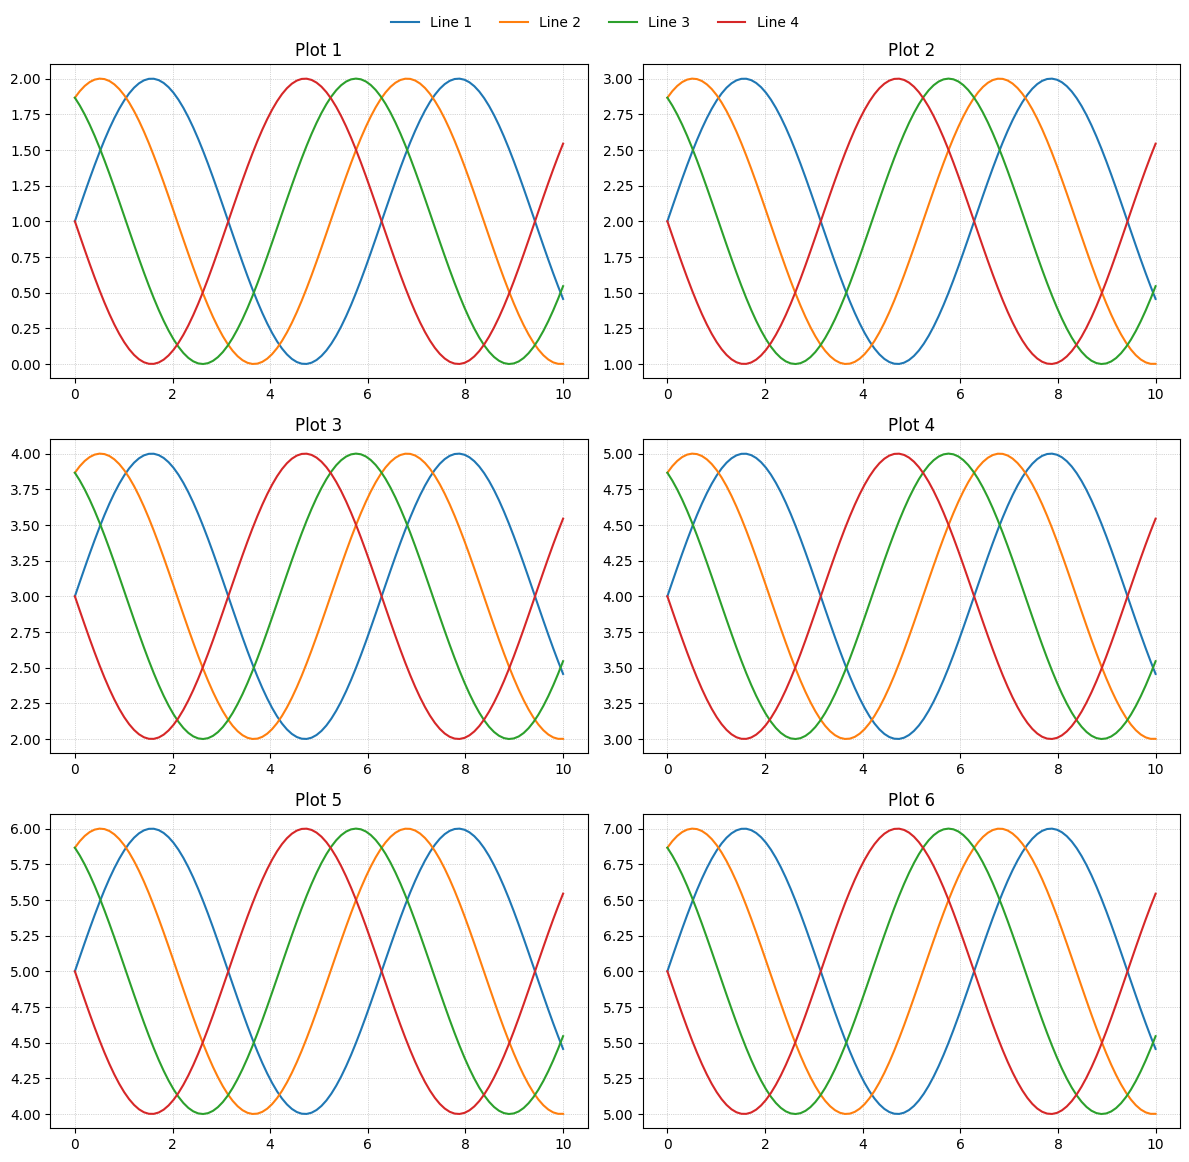

In [4]:
import matplotlib.pyplot as plt
import numpy as np

"""
Multi‑panel plot template
=========================
Creates a 3 × 2 grid of sub‑plots (6 panels total).  Each panel shows the same
four line‑series, and *one single shared legend* is placed on the figure
instead of six individual legends.  Replace the demo data generation section
with your own data as needed.
"""

# ---------------------------------------------------------------------------
# Demo data ‑‑ replace this with your own
# ---------------------------------------------------------------------------
# x‑axis: 100 points between 0 and 10
x = np.linspace(0, 10, 100)

# Four y‑series (here: sine waves phase‑shifted for illustration)
y_series = [np.sin(x + phase) for phase in np.linspace(0, np.pi, 4)]
label_names = [f"Line {i+1}" for i in range(len(y_series))]

# ---------------------------------------------------------------------------
# Figure & axes layout
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharex=False, sharey=False)
axes = axes.flatten()  # flatten for easy iteration (length == 6)

# ---------------------------------------------------------------------------
# Populate each subplot
# ---------------------------------------------------------------------------
for panel_id, ax in enumerate(axes, start=1):
    # Draw the four lines
    for y, lbl in zip(y_series, label_names):
        ax.plot(x, y + panel_id, label=lbl)  # +panel_id just offsets each panel visually

    # Cosmetic touches
    ax.set_title(f"Plot {panel_id}")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)

# ---------------------------------------------------------------------------
# Single, figure‑level legend (one for all six panels)
# ---------------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",  # place above all sub‑plots
           ncol=len(label_names),
           bbox_to_anchor=(0.5, 0.97),
           frameon=False)

# ---------------------------------------------------------------------------
# Layout adjustments & rendering
# ---------------------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at the top for legend
plt.show()


   exp_name  gap_gen_greedy  gap_gen_greedy_std  gap_gen_samp  \
0         1       12.404029            0.462434      6.530193   
1         5       11.922671            0.166709      6.313270   
2        10       11.727229            0.413622      5.919372   
3        25       11.761244            0.304538      5.999139   
4        50       11.501633            0.280927      6.294643   
5        75       11.873673            0.498792      6.146906   
6       100       11.187021            0.351990      5.874132   

   gap_gen_samp_std  gap_bench_greedy  gap_bench_greedy_std  gap_bench_samp  \
0          0.471306         11.796359              0.520971        6.503485   
1          0.035109         10.493891              0.448918        6.240891   
2          0.162734         10.501488              0.339301        6.161433   
3          0.326422         10.205156              0.385018        6.309311   
4          0.182047         10.666651              0.447786        6.429894   
5    

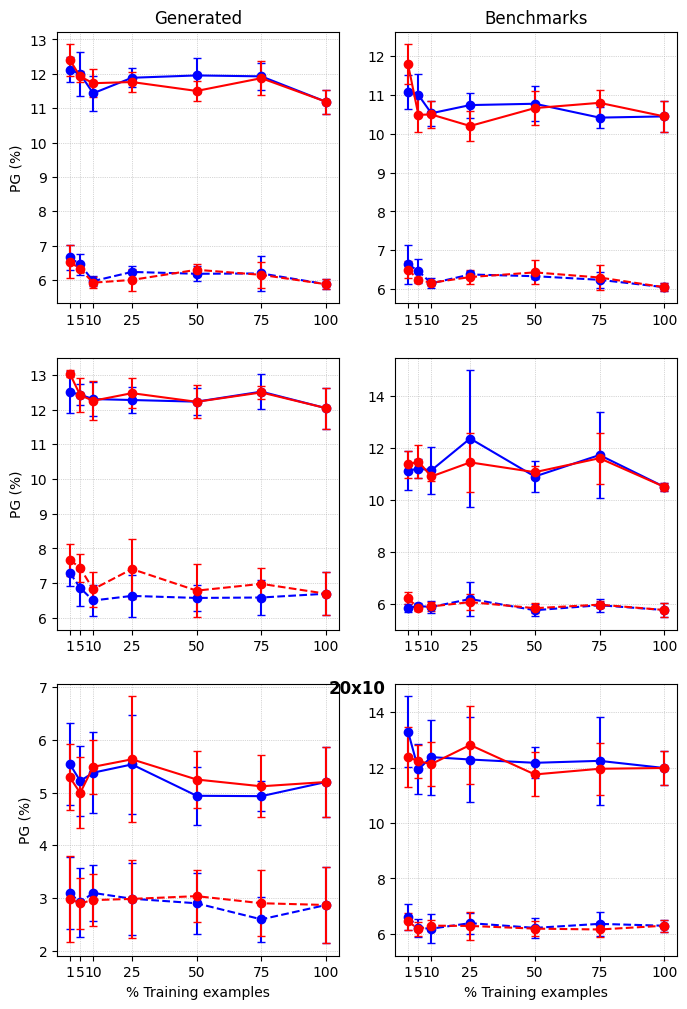

In [5]:
def create_dataset_size_plot(folder_random, folder_instance):



# ---------------------------------------------------------------------------
# 3. Figure and axes
# ---------------------------------------------------------------------------
    fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(8, 12), sharex=False, sharey=False)
    # axes = axes.flatten()
    res_10_5_random = pd.read_csv(os.path.join(folder_random, "10_5.csv"))
    res_15_10_random = pd.read_csv(os.path.join(folder_random, "15_10.csv"))
    res_20_10_random = pd.read_csv(os.path.join(folder_random, "20_10.csv"))

    res_10_5_instance = pd.read_csv(os.path.join(folder_instance, "10_5.csv"))
    res_15_10_instance = pd.read_csv(os.path.join(folder_instance, "15_10.csv"))
    res_20_10_instance = pd.read_csv(os.path.join(folder_instance, "20_10.csv"))
    res_10_5_instance["exp_name"] = res_10_5_instance["exp_name"] // 5
    res_15_10_instance["exp_name"] = res_15_10_instance["exp_name"] // 5
    res_20_10_instance["exp_name"] = res_20_10_instance["exp_name"] // 5



    print(res_10_5_instance)
    x = res_10_5_instance["exp_name"]

    ax[0][0].errorbar(
                x,
                res_10_5_random["gap_gen_greedy"],
                yerr=res_10_5_random["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax[0][0].errorbar(
                x,
                res_10_5_random["gap_gen_samp"],
                yerr=res_10_5_random["gap_gen_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )

    ax[0][0].errorbar(
                x,
                res_10_5_instance["gap_gen_greedy"],
                yerr=res_10_5_instance["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax[0][0].errorbar(
                x,
                res_10_5_instance["gap_gen_samp"],
                yerr=res_10_5_instance["gap_gen_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    ax[0][0].set_title("Generated")
    # ax[0][0].set_xlabel("% Training examples")
    ax[0][0].set_ylabel("PG (%)")
    ax[0][0].set_xticks(x)
    ax[0][0].set_xticklabels(x.astype(str))  # show only exp_name ticks
    ax[0][0].grid(True, which="both", linestyle=":", linewidth=0.5)

    ax[0][1].errorbar(
                x,
                res_10_5_random["gap_bench_greedy"],
                yerr=res_10_5_random["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax[0][1].errorbar(
                x,
                res_10_5_random["gap_bench_samp"],
                yerr=res_10_5_random["gap_bench_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )
    ax[0][1].errorbar(
                x,
                res_10_5_instance["gap_bench_greedy"],
                yerr=res_10_5_instance["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax[0][1].errorbar(
                x,
                res_10_5_instance["gap_bench_samp"],
                yerr=res_10_5_instance["gap_bench_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    ax[0][1].set_title("Benchmarks")
    ax[0][1].grid(True, which="both", linestyle=":", linewidth=0.5)
    ax[0][1].set_xticks(x)
    ax[0][1].set_xticklabels(x.astype(str))

    # ----------------------------------------
    # 15x10
    ax[1][0].errorbar(
                x,
                res_15_10_random["gap_gen_greedy"],
                yerr=res_15_10_random["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax[1][0].errorbar(
                x,
                res_15_10_random["gap_gen_samp"],
                yerr=res_15_10_random["gap_gen_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )

    ax[1][0].errorbar(
                x,
                res_15_10_instance["gap_gen_greedy"],
                yerr=res_15_10_instance["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax[1][0].errorbar(
                x,
                res_15_10_instance["gap_gen_samp"],
                yerr=res_15_10_instance["gap_gen_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[1][0].set_title("Generated")
    # ax[0][0].set_xlabel("% Training examples")
    ax[1][0].set_ylabel("PG (%)")
    ax[1][0].set_xticks(x)
    ax[1][0].set_xticklabels(x.astype(str))  # show only exp_name ticks
    ax[1][0].grid(True, which="both", linestyle=":", linewidth=0.5)

    ax[1][1].errorbar(
                x,
                res_15_10_random["gap_bench_greedy"],
                yerr=res_15_10_random["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax[1][1].errorbar(
                x,
                res_15_10_random["gap_bench_samp"],
                yerr=res_15_10_random["gap_bench_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )
    ax[1][1].errorbar(
                x,
                res_15_10_instance["gap_bench_greedy"],
                yerr=res_15_10_instance["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax[1][1].errorbar(
                x,
                res_15_10_instance["gap_bench_samp"],
                yerr=res_15_10_instance["gap_bench_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[1][1].set_title("Benchmarks")
    ax[1][1].grid(True, which="both", linestyle=":", linewidth=0.5)
    ax[1][1].set_xticks(x)
    ax[1][1].set_xticklabels(x.astype(str))

    # ---------------------------------------- 20x10
    ax[2][0].errorbar(
                x,
                res_20_10_random["gap_gen_greedy"],
                yerr=res_20_10_random["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax[2][0].errorbar(
                x,
                res_20_10_random["gap_gen_samp"],
                yerr=res_20_10_random["gap_gen_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )

    ax[2][0].errorbar(
                x,
                res_20_10_instance["gap_gen_greedy"],
                yerr=res_20_10_instance["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax[2][0].errorbar(
                x,
                res_20_10_instance["gap_gen_samp"],
                yerr=res_20_10_instance["gap_gen_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[2][0].set_title("Generated")
    # ax[0][0].set_xlabel("% Training examples")
    ax[2][0].set_ylabel("PG (%)")
    ax[2][0].set_xlabel("% Training examples")

    ax[2][0].set_xticks(x)
    ax[2][0].set_xticklabels(x.astype(str))  # show only exp_name ticks
    ax[2][0].grid(True, which="both", linestyle=":", linewidth=0.5)

    ax[2][1].errorbar(
                x,
                res_20_10_random["gap_bench_greedy"],
                yerr=res_20_10_random["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax[2][1].errorbar(
                x,
                res_20_10_random["gap_bench_samp"],
                yerr=res_20_10_random["gap_bench_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )
    ax[2][1].errorbar(
                x,
                res_20_10_instance["gap_bench_greedy"],
                yerr=res_20_10_instance["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax[2][1].errorbar(
                x,
                res_20_10_instance["gap_bench_samp"],
                yerr=res_20_10_instance["gap_bench_samp_std"],
                marker="o",
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[2][1].set_title("Benchmarks")
    fig.text(0.5, 0.98 - 2*0.32, "20x10",
             ha='center', va='top',
             fontsize=12, weight='bold')
    ax[2][1].grid(True, which="both", linestyle=":", linewidth=0.5)
    ax[2][1].set_xticks(x)
    ax[2][1].set_xticklabels(x.astype(str))
    ax[2][1].set_xlabel("% Training examples")
    # ax[2][1].set_ylabel("20x10" ,                # the text
    #                       labelpad=0,          # shift it away from the axis
    #                       rotation=0,           # horizontal text
    #                       va='center',          # vertically centred on the row
    #                       fontsize=12,
    #                       weight='bold')

    # ax[0][0].set_xlabel("% Training examples")
    # ax[0][0].set_ylabel("PG (%)")
    # ax[0][0].set_xticks(x)
    # ax[0][0].set_xticklabels(x.astype(str))
    return

#     for idx, ax in enumerate(axes):
#
#
#     for idx, (ax, path) in enumerate(zip(axes, csv_paths), start=1):
#         df = pd.read_csv(path).sort_values("exp_name")
#
#         x = df["exp_name"]
#         for val_col, std_col, label in metrics:
#             ax.errorbar(
#                 x,
#                 df[val_col],
#                 yerr=df[std_col],
#                 marker="o",
#                 linestyle="-",
#                 capsize=3,
#                 label=label,
#             )
#
#     # Formatting
#         title = os.path.splitext(os.path.basename(path))[0].replace("_", " ")
#         ax.set_title(title)
#         ax.set_xlabel("% Training examples")
#         ax.set_ylabel("Gap result")
#         ax.set_xticks(x)
#         ax.set_xticklabels(x.astype(str))  # show only exp_name ticks
#         ax.grid(True, which="both", linestyle=":", linewidth=0.5)
# #
# # # Hide any unused axes if <6 CSVs
# # for ax in axes[len(csv_paths):]:
# #     ax.set_visible(False)
#
# # ---------------------------------------------------------------------------
# # Shared legend – use handles from the first plotted axis
# # ---------------------------------------------------------------------------
#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(
#         handles,
#         labels,
#         loc="upper center",
#         ncol=len(labels),
#         bbox_to_anchor=(0.5, 0.97),
#         frameon=False,
#     )
#
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # keep space for the legend
# plt.show()

create_dataset_size_plot("./results_dataset_size/random_size", "./results_dataset_size/instance_size")

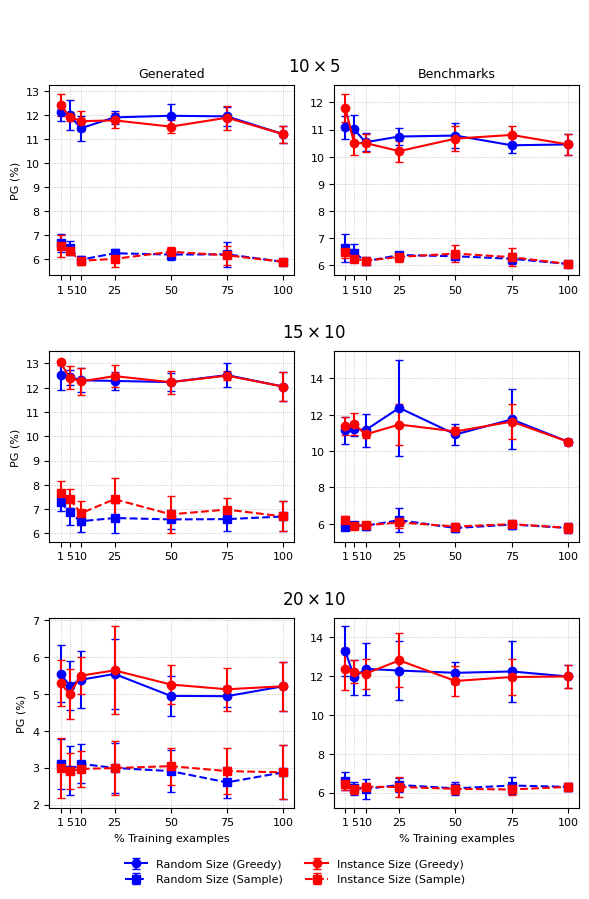

In [6]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def create_dataset_size_plot(folder_random, folder_instance):



# ---------------------------------------------------------------------------
# 3. Figure and axes
# ---------------------------------------------------------------------------
#     fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(8, 12), sharex=False, sharey=False)
    fig = plt.figure(figsize=(6, 9))
    # axes = axes.flatten()
    res_10_5_random = pd.read_csv(os.path.join(folder_random, "10_5.csv"))
    res_15_10_random = pd.read_csv(os.path.join(folder_random, "15_10.csv"))
    res_20_10_random = pd.read_csv(os.path.join(folder_random, "20_10.csv"))

    res_10_5_instance = pd.read_csv(os.path.join(folder_instance, "10_5.csv"))
    res_15_10_instance = pd.read_csv(os.path.join(folder_instance, "15_10.csv"))
    res_20_10_instance = pd.read_csv(os.path.join(folder_instance, "20_10.csv"))
    res_10_5_instance["exp_name"] = res_10_5_instance["exp_name"] // 5
    res_15_10_instance["exp_name"] = res_15_10_instance["exp_name"] // 5
    res_20_10_instance["exp_name"] = res_20_10_instance["exp_name"] // 5

    gs  = GridSpec(nrows=6, ncols=2,
               height_ratios=[ .4, 1, .4, 1, .4, 1],   # .25 → gap size
               hspace=0.0,                               # no extra padding
               figure=fig)
    error_bar_symbol_random = "o"
    error_bar_symbol_instance = "s"


    # print(res_10_5_instance)
    x = res_10_5_instance["exp_name"]
    log_ticks = x
    def format_axis(ax_left, ax_right, title_left, title_right):
        # ax.set_xscale("log")
        ax_left.set_xticks(log_ticks)
        ax_left.set_ylabel("PG (%)", fontsize=8)

        ax_left.set_xticklabels([str(t) for t in log_ticks], fontsize=8)
        ax_left.set_title(title_left, fontsize=9)
        ax_left.tick_params(axis='both', which='major', labelsize=8)
        ax_left.grid(True, which="both", linestyle=":", linewidth=0.5)

        ax_right.set_xticks(log_ticks)
        ax_right.set_xticklabels([str(t) for t in log_ticks], fontsize=8)
        ax_right.set_title(title_right, fontsize=9)
        ax_right.tick_params(axis='both', which='major', labelsize=8)
        ax_right.grid(True, which="both", linestyle=":", linewidth=0.5)

    axes = []
    ax_gap0 = fig.add_subplot(gs[0, :])
    ax_gap0.axis('off')                            # hide axis frame
    # ax_gap0.text(0.02, 0.5, "10x5",         # place label
    #             # ha='left', va='center',
    #             fontsize=14, weight='bold')
    ax_gap0.text(
        0.5, 0.25,                # x, y in *Axes* coordinates (0‑1)
        r"$10\times5$",
        ha='center', va='center', # centre both directions
        fontsize=12,
        transform=ax_gap0.transAxes
    )
    ax_left0 = fig.add_subplot(gs[1, 0])
    ax_right0 = fig.add_subplot(gs[1, 1])
    axes.extend([ax_left0, ax_right0])

    ax_left0.errorbar(
                x,
                res_10_5_random["gap_gen_greedy"],
                yerr=res_10_5_random["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax_left0.errorbar(
                x,
                res_10_5_random["gap_gen_samp"],
                yerr=res_10_5_random["gap_gen_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )

    ax_left0.errorbar(
                x,
                res_10_5_instance["gap_gen_greedy"],
                yerr=res_10_5_instance["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax_left0.errorbar(
                x,
                res_10_5_instance["gap_gen_samp"],
                yerr=res_10_5_instance["gap_gen_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax_left0.set_title("Generated", fontsize=10)
    # # ax[0][0].set_xlabel("% Training examples")
    # ax_left0.set_ylabel("PG (%)")
    # ax_left0.set_xticks(x)
    # ax_left0.set_xticklabels(x.astype(str))  # show only exp_name ticks
    # ax_left0.grid(True, which="both", linestyle=":", linewidth=0.5)
    # ax_left0.set_xticks(log_ticks)
    # format_axis(ax_left0, "Generated")


    ax_right0.errorbar(
                x,
                res_10_5_random["gap_bench_greedy"],
                yerr=res_10_5_random["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax_right0.errorbar(
                x,
                res_10_5_random["gap_bench_samp"],
                yerr=res_10_5_random["gap_bench_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )
    ax_right0.errorbar(
                x,
                res_10_5_instance["gap_bench_greedy"],
                yerr=res_10_5_instance["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax_right0.errorbar(
                x,
                res_10_5_instance["gap_bench_samp"],
                yerr=res_10_5_instance["gap_bench_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax_right0.set_title("Benchmarks", fontsize=10)
    # ax_right0.grid(True, which="both", linestyle=":", linewidth=0.5)
    # ax_right0.set_xticks(x)
    # ax_right0.set_xticklabels(x.astype(str))
    format_axis(ax_left0, ax_right0, "Generated", "Benchmarks")

    # ----------------------------------------
    # 15x10
    ax_gap1 = fig.add_subplot(gs[2, :])
    ax_gap1.axis('off')                            # hide axis frame
    # ax_gap0.text(0.02, 0.5, "10x5",         # place label
    #             # ha='left', va='center',
    #             fontsize=14, weight='bold')
    ax_gap1.text(
        0.5, 0.25,                 # x, y in *Axes* coordinates (0‑1)
        r"$15\times 10$",
        ha='center', va='center', # centre both directions
        fontsize=12,
        transform=ax_gap1.transAxes
    )
    ax_left1 = fig.add_subplot(gs[3, 0])
    ax_right1 = fig.add_subplot(gs[3, 1])
    axes.extend([ax_left1, ax_right1])
    ax_left1.errorbar(
                x,
                res_15_10_random["gap_gen_greedy"],
                yerr=res_15_10_random["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax_left1.errorbar(
                x,
                res_15_10_random["gap_gen_samp"],
                yerr=res_15_10_random["gap_gen_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )

    ax_left1.errorbar(
                x,
                res_15_10_instance["gap_gen_greedy"],
                yerr=res_15_10_instance["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax_left1.errorbar(
                x,
                res_15_10_instance["gap_gen_samp"],
                yerr=res_15_10_instance["gap_gen_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[1][0].set_title("Generated")
    # ax[0][0].set_xlabel("% Training examples")
    # ax_left1.set_ylabel("PG (%)")
    # ax_left1.set_xticks(x)
    # ax_left1.set_xticklabels(x.astype(str))  # show only exp_name ticks
    # ax_left1.grid(True, which="both", linestyle=":", linewidth=0.5)

    ax_right1.errorbar(
                x,
                res_15_10_random["gap_bench_greedy"],
                yerr=res_15_10_random["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax_right1.errorbar(
                x,
                res_15_10_random["gap_bench_samp"],
                yerr=res_15_10_random["gap_bench_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )
    ax_right1.errorbar(
                x,
                res_15_10_instance["gap_bench_greedy"],
                yerr=res_15_10_instance["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax_right1.errorbar(
                x,
                res_15_10_instance["gap_bench_samp"],
                yerr=res_15_10_instance["gap_bench_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[1][1].set_title("Benchmarks")
    # ax_right1.grid(True, which="both", linestyle=":", linewidth=0.5)
    # ax_right1.set_xticks(x)
    # ax_right1.set_xticklabels(x.astype(str))
    format_axis(ax_left1, ax_right1, None, None)

    #
    # # ---------------------------------------- 20x10
    ax_gap2 = fig.add_subplot(gs[4, :])
    ax_gap2.axis('off')                            # hide axis frame
    # ax_gap0.text(0.02, 0.5, "10x5",         # place label
    #             # ha='left', va='center',
    #             fontsize=14, weight='bold')
    ax_gap2.text(
        0.5, 0.25,                 # x, y in *Axes* coordinates (0‑1)
        r"$20\times 10$",
        ha='center', va='center', # centre both directions
        fontsize=12, weight='bold',
        transform=ax_gap2.transAxes
    )
    ax_left2 = fig.add_subplot(gs[5, 0])
    ax_right2 = fig.add_subplot(gs[5, 1])
    axes.extend([ax_left2, ax_right2])
    ax_left2.errorbar(
                x,
                res_20_10_random["gap_gen_greedy"],
                yerr=res_20_10_random["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax_left2.errorbar(
                x,
                res_20_10_random["gap_gen_samp"],
                yerr=res_20_10_random["gap_gen_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )

    ax_left2.errorbar(
                x,
                res_20_10_instance["gap_gen_greedy"],
                yerr=res_20_10_instance["gap_gen_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax_left2.errorbar(
                x,
                res_20_10_instance["gap_gen_samp"],
                yerr=res_20_10_instance["gap_gen_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[2][0].set_title("Generated")
    # ax[0][0].set_xlabel("% Training examples")
    # ax_left2.set_ylabel("PG (%)")
    # ax_left2.set_xlabel("% Training examples")
    #
    # ax_left2.set_xticks(x)
    # ax_left2.set_xticklabels(x.astype(str))  # show only exp_name ticks
    # ax_left2.grid(True, which="both", linestyle=":", linewidth=0.5)

    ax_right2.errorbar(
                x,
                res_20_10_random["gap_bench_greedy"],
                yerr=res_20_10_random["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="blue",
                label="Random Size (Greedy)",
            )
    ax_right2.errorbar(
                x,
                res_20_10_random["gap_bench_samp"],
                yerr=res_20_10_random["gap_bench_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="blue",
                label="Random Size (Sample)",
            )
    ax_right2.errorbar(
                x,
                res_20_10_instance["gap_bench_greedy"],
                yerr=res_20_10_instance["gap_bench_greedy_std"],
                marker="o",
                linestyle="-",
                capsize=3,
                color="red",
                label="Instance Size (Greedy)",
            )
    ax_right2.errorbar(
                x,
                res_20_10_instance["gap_bench_samp"],
                yerr=res_20_10_instance["gap_bench_samp_std"],
                marker=error_bar_symbol_instance,
                linestyle="--",
                capsize=3,
                color="red",
                label="Instance Size (Sample)",
            )
    # pri
    # ax[2][1].set_title("Benchmarks")
    # fig.text(0.5, 0.98 - 2*0.32, "20x10",
    #          ha='center', va='top',
    #          fontsize=12, weight='bold')
    # ax_right2.grid(True, which="both", linestyle=":", linewidth=0.5)
    # ax_right2.set_xticks(x)
    # ax_right2.set_xticklabels(x.astype(str))
    ax_right2.set_xlabel("% Training examples", fontsize=8)
    ax_left2.set_xlabel("% Training examples", fontsize=8)
    format_axis(ax_left2, ax_right2, None, None)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
    handles, labels,
    loc='lower center',         # below the grid
    ncol=2,           # one row
    bbox_to_anchor=(0.5, -0.0005),# (x = 50 %, y = −2 % of fig height)
    frameon=False,
    fontsize=8
    )
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    fig.savefig("./plot/dataset_size.png", dpi=500, bbox_inches='tight', transparent=True)

create_dataset_size_plot("./results_dataset_size/random_size", "./results_dataset_size/instance_size")

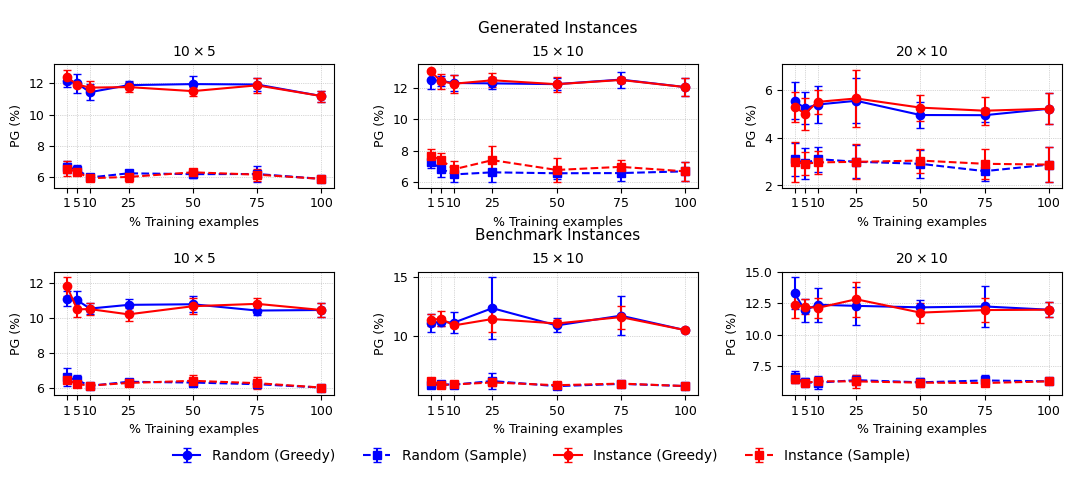

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def create_transformed_dataset_size_plot(folder_random, folder_instance):
    # Read CSVs
    res_random = {
        "10_5": pd.read_csv(os.path.join(folder_random, "10_5.csv")),
        "15_10": pd.read_csv(os.path.join(folder_random, "15_10.csv")),
        "20_10": pd.read_csv(os.path.join(folder_random, "20_10.csv")),
    }
    res_instance = {
        "10_5": pd.read_csv(os.path.join(folder_instance, "10_5.csv")),
        "15_10": pd.read_csv(os.path.join(folder_instance, "15_10.csv")),
        "20_10": pd.read_csv(os.path.join(folder_instance, "20_10.csv")),
    }

    for key in res_instance:
        res_instance[key]["exp_name"] = res_instance[key]["exp_name"] // 5

    # Set up figure and gridspec
    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(nrows=4, ncols=3, figure=fig, wspace=0.3, hspace=0.4,
                  height_ratios=[0.2, 1, 0.2, 1])

    size_labels = {"10_5": r"$10\times5$", "15_10": r"$15\times10$", "20_10": r"$20\times10$"}
    x = res_instance["10_5"]["exp_name"]

    def plot_subplot(ax, data_random, data_instance, metric_prefix, title):
        # Random data
        ax.errorbar(x, data_random[f"{metric_prefix}_greedy"], yerr=data_random[f"{metric_prefix}_greedy_std"],
                    marker="o", linestyle="-", capsize=3, color="blue", label="Random (Greedy)")
        ax.errorbar(x, data_random[f"{metric_prefix}_samp"], yerr=data_random[f"{metric_prefix}_samp_std"],
                    marker="s", linestyle="--", capsize=3, color="blue", label="Random (Sample)")
        # Instance data
        ax.errorbar(x, data_instance[f"{metric_prefix}_greedy"], yerr=data_instance[f"{metric_prefix}_greedy_std"],
                    marker="o", linestyle="-", capsize=3, color="red", label="Instance (Greedy)")
        ax.errorbar(x, data_instance[f"{metric_prefix}_samp"], yerr=data_instance[f"{metric_prefix}_samp_std"],
                    marker="s", linestyle="--", capsize=3, color="red", label="Instance (Sample)")
        ax.set_title(title, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(x.astype(str), fontsize=9)
        ax.tick_params(axis='both', which='major', labelsize=9)
        ax.grid(True, linestyle=":", linewidth=0.5)
        ax.set_xlabel("% Training examples", fontsize=9)
        ax.set_ylabel("PG (%)", fontsize=9)

    ax_gap1 = fig.add_subplot(gs[0, :])
    ax_gap1.axis('off')                            # hide axis frame
    # ax_gap0.text(0.02, 0.5, "10x5",         # place label
    #             # ha='left', va='center',
    #             fontsize=14, weight='bold')
    ax_gap1.text(
        0.5, 0.25,                 # x, y in *Axes* coordinates (0‑1)
        "Generated Instances",
        ha='center', va='center', # centre both directions
        fontsize=11,
        transform=ax_gap1.transAxes
    )
    # Plot Generated (row 0)
    for i, key in enumerate(["10_5", "15_10", "20_10"]):
        ax = fig.add_subplot(gs[1, i])
        plot_subplot(ax, res_random[key], res_instance[key], "gap_gen", size_labels[key])
        # if i == 1:
        #     ax.set_title(f"{size_labels[key]}\nGenerated", fontsize=11)

    # Plot Benchmarks (row 1)
    ax_gap2 = fig.add_subplot(gs[2, :])
    ax_gap2.axis('off')                            # hide axis frame
    # ax_gap0.text(0.02, 0.5, "10x5",         # place label
    #             # ha='left', va='center',
    #             fontsize=14, weight='bold')
    ax_gap2.text(
        0.5, 0.25,                 # x, y in *Axes* coordinates (0‑1)
        "Benchmark Instances",
        ha='center', va='center', # centre both directions
        fontsize=11,
        transform=ax_gap2.transAxes
    )
    for i, key in enumerate(["10_5", "15_10", "20_10"]):
        ax = fig.add_subplot(gs[3, i])
        plot_subplot(ax, res_random[key], res_instance[key], "gap_bench", size_labels[key])
        # if i == 1:
        #     ax.set_title(f"{size_labels[key]}\nBenchmarks", fontsize=11)

    # Add legend to bottom center
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=10)

    # fig.tight_layout(rect=[0, 0.04, 1, 1])
    fig.savefig("./plot/dataset_size.png", dpi=800, bbox_inches='tight', transparent=True)

# Example usage:
create_transformed_dataset_size_plot("./results_dataset_size/random_size", "./results_dataset_size/instance_size")

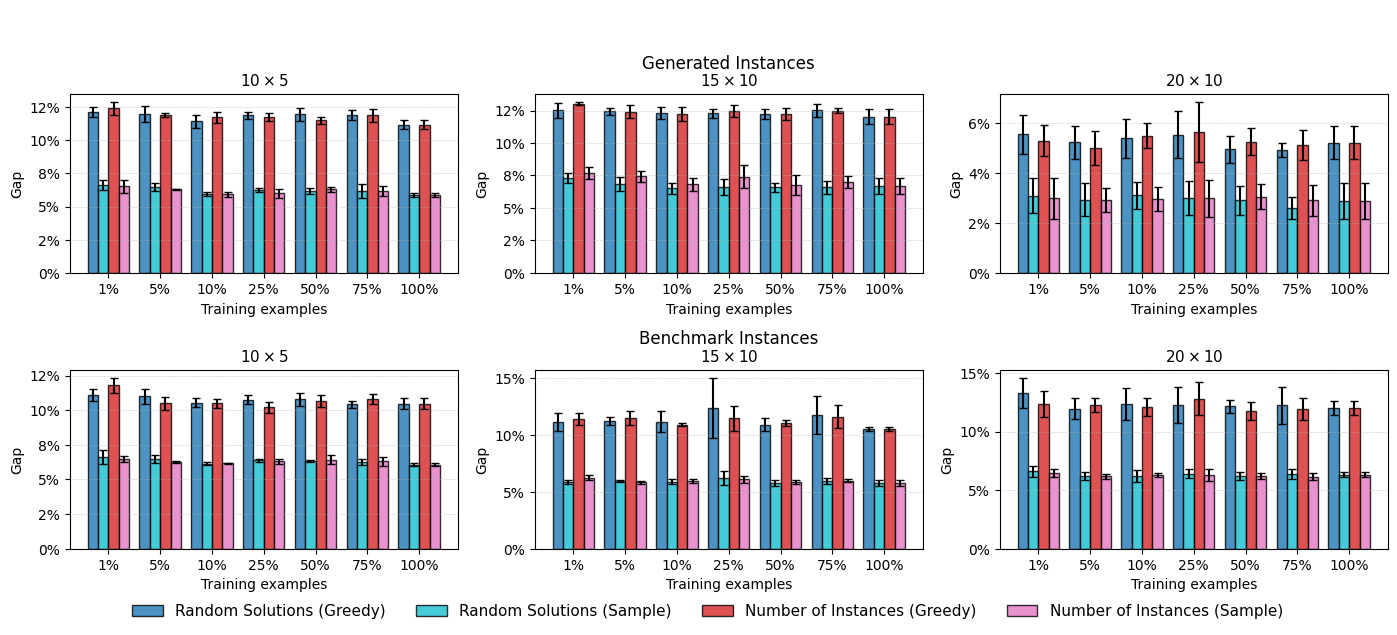

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter
import numpy as np

def create_transformed_dataset_size_barchart(folder_random, folder_instance):
    # Read CSVs
    res_random = {
        "10_5": pd.read_csv(os.path.join(folder_random, "10_5.csv")),
        "15_10": pd.read_csv(os.path.join(folder_random, "15_10.csv")),
        "20_10": pd.read_csv(os.path.join(folder_random, "20_10.csv")),
    }
    res_instance = {
        "10_5": pd.read_csv(os.path.join(folder_instance, "10_5.csv")),
        "15_10": pd.read_csv(os.path.join(folder_instance, "15_10.csv")),
        "20_10": pd.read_csv(os.path.join(folder_instance, "20_10.csv")),
    }

    for key in res_instance:
        res_instance[key]["exp_name"] = res_instance[key]["exp_name"] // 5

    fig = plt.figure(figsize=(17, 7))
    gs = GridSpec(nrows=4, ncols=3, figure=fig, wspace=0.2, hspace=0.1,
                  height_ratios=[0.4, 1, 0.4, 1])

    size_labels = {"10_5": r"$10\times5$", "15_10": r"$15\times10$", "20_10": r"$20\times10$"}

    # Helper function to plot a bar chart with error bars
    def plot_subplot(ax, data_random, data_instance, metric_prefix, title):
        x = np.arange(len(data_random["exp_name"]))
        bar_width = 0.2

        # Prepare bar heights and errors
        bars = [
            (data_random[f"{metric_prefix}_greedy"], data_random[f"{metric_prefix}_greedy_std"], "Random Solutions (Greedy)"),
            (data_random[f"{metric_prefix}_samp"], data_random[f"{metric_prefix}_samp_std"], "Random Solutions (Sample)"),
            (data_instance[f"{metric_prefix}_greedy"], data_instance[f"{metric_prefix}_greedy_std"], "Number of Instances (Greedy)"),
            (data_instance[f"{metric_prefix}_samp"], data_instance[f"{metric_prefix}_samp_std"], "Number of Instances (Sample)")
        ]

        colors = ["tab:blue", "tab:cyan", "tab:red", "tab:pink"]
        positions = [
            x - 1.5*bar_width,
            x - 0.5*bar_width,
            x + 0.5*bar_width,
            x + 1.5*bar_width,
        ]

        for idx, (heights, errors, label) in enumerate(bars):
            ax.bar(
                positions[idx], heights, bar_width,
                yerr=errors,
                capsize=3,
                label=label,
                color=colors[idx],
                edgecolor="black",
                alpha=0.8
            )

        ax.set_title(title, fontsize=11)
        ax.set_xticks(x)
        x_labels = data_random["exp_name"].astype(str).tolist()
        x_labels = [f"{x}%" for x in x_labels]
        ax.set_xticklabels(x_labels, fontsize=10)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(True, linestyle=":", linewidth=0.5, axis="y")
        ax.set_xlabel("Training examples", fontsize=10)
        ax.set_ylabel("Gap", fontsize=10)

    # Title bar
    ax_gap1 = fig.add_subplot(gs[0, :])
    ax_gap1.axis('off')
    ax_gap1.text(
        0.5, 0.25, "Generated Instances",
        ha='center', va='center', fontsize=12, transform=ax_gap1.transAxes
    )

    # Generated instances
    for i, key in enumerate(["10_5", "15_10", "20_10"]):
        ax = fig.add_subplot(gs[1, i])
        plot_subplot(ax, res_random[key], res_instance[key], "gap_gen", size_labels[key])

    # Separator bar
    ax_gap2 = fig.add_subplot(gs[2, :])
    ax_gap2.axis('off')
    ax_gap2.text(
        0.5, 0.25, "Benchmark Instances",
        ha='center', va='center', fontsize=12, transform=ax_gap2.transAxes
    )

    # Benchmark instances
    for i, key in enumerate(["10_5", "15_10", "20_10"]):
        ax = fig.add_subplot(gs[3, i])
        plot_subplot(ax, res_random[key], res_instance[key], "gap_bench", size_labels[key])

    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=11)

    fig.savefig("./plot/dataset_size_barchart.png", dpi=800, bbox_inches='tight', transparent=True)

# Example usage:
create_transformed_dataset_size_barchart("./results_dataset_size/random_size", "./results_dataset_size/instance_size")


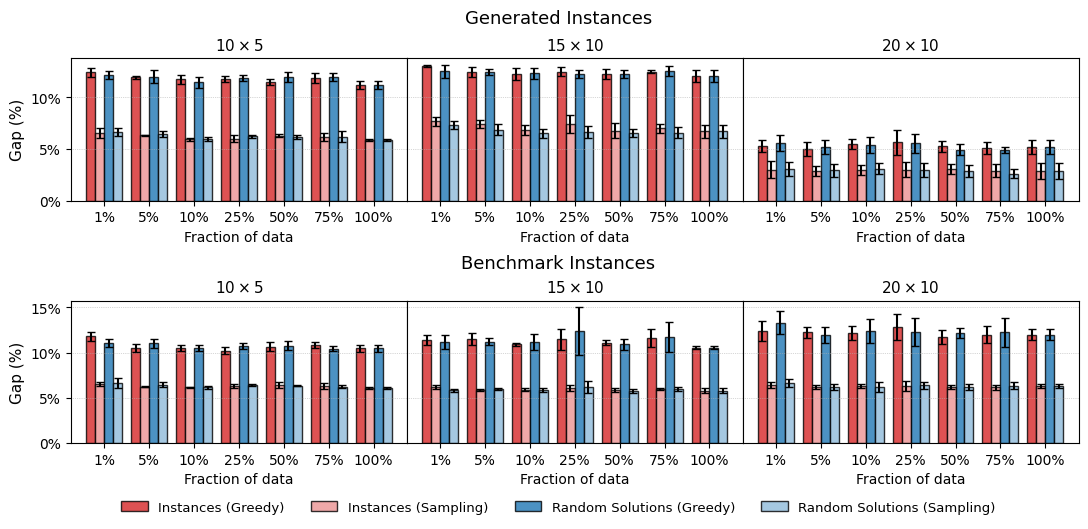

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.colors as mcolors

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return [(1 - amount) * comp + amount for comp in c]

def create_transformed_dataset_size_barchart(folder_random, folder_instance):
    # Read CSVs
    res_random = {
        "10_5": pd.read_csv(os.path.join(folder_random, "10_5.csv")),
        "15_10": pd.read_csv(os.path.join(folder_random, "15_10.csv")),
        "20_10": pd.read_csv(os.path.join(folder_random, "20_10.csv")),
    }
    res_instance = {
        "10_5": pd.read_csv(os.path.join(folder_instance, "10_5.csv")),
        "15_10": pd.read_csv(os.path.join(folder_instance, "15_10.csv")),
        "20_10": pd.read_csv(os.path.join(folder_instance, "20_10.csv")),
    }

    for key in res_instance:
        res_instance[key]["exp_name"] = res_instance[key]["exp_name"] // 5

    size_labels = {"10_5": r"$10\times5$", "15_10": r"$15\times10$", "20_10": r"$20\times10$"}

    # Prepare figure and axes: 2 rows, 3 columns
    fig, axes = plt.subplots(
        nrows=2, ncols=3, figsize=(13, 5),
        sharey='row', gridspec_kw={'wspace': 0, 'hspace': 0.7}
    )

    # Helper function to plot a bar chart with error bars
    def plot_subplot(ax, data_random, data_instance, metric_prefix, title, show_ylabel=False):
        x = np.arange(len(data_random["exp_name"]))
        bar_width = 0.2

        bars = [
            (data_instance[f"{metric_prefix}_greedy"], data_instance[f"{metric_prefix}_greedy_std"], "Instances (Greedy)"),
            (data_instance[f"{metric_prefix}_samp"], data_instance[f"{metric_prefix}_samp_std"], "Instances (Sampling)"),
            (data_random[f"{metric_prefix}_greedy"], data_random[f"{metric_prefix}_greedy_std"], "Random Solutions (Greedy)"),
            (data_random[f"{metric_prefix}_samp"], data_random[f"{metric_prefix}_samp_std"], "Random Solutions (Sampling)"),

        ]
        colors = ["tab:red", lighten_color("tab:red"), "tab:blue", lighten_color("tab:blue")]
        positions = [
            x - 1.5*bar_width,
            x - 0.5*bar_width,
            x + 0.5*bar_width,
            x + 1.5*bar_width,
        ]

        for idx, (heights, errors, label) in enumerate(bars):
            ax.bar(
                positions[idx], heights, bar_width,
                yerr=errors, capsize=3,
                label=label, color=colors[idx],
                edgecolor="black", alpha=0.8
            )

        ax.set_title(title, fontsize=11)
        ax.set_xticks(x)
        x_labels = data_random["exp_name"].astype(str).tolist()
        x_labels = [f"{x}%" for x in x_labels]
        ax.set_xticklabels(x_labels, fontsize=10)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.grid(True, linestyle=":", linewidth=0.5, axis="y")
        ax.set_xlabel("Fraction of data", fontsize=10)
        if show_ylabel:
            ax.set_ylabel("Gap (%)", fontsize=11)
        else:
            ax.set_ylabel("")

    # Top row: Generated Instances
    for i, key in enumerate(["10_5", "15_10", "20_10"]):
        show_ylabel = (i == 0)
        plot_subplot(axes[0, i], res_random[key], res_instance[key], "gap_gen", size_labels[key], show_ylabel=show_ylabel)

    # Bottom row: Benchmark Instances
    for i, key in enumerate(["10_5", "15_10", "20_10"]):
        show_ylabel = (i == 0)
        plot_subplot(axes[1, i], res_random[key], res_instance[key], "gap_bench", size_labels[key], show_ylabel=show_ylabel)

    # Remove space between y-axis and plots
    for ax_row in axes:
        for ax in ax_row[1:]:
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.yaxis.set_tick_params(left=False)

    # Set single y-label per row using fig.text
    # fig.text(0.04, 0.72, "Gap (%)", va='center', ha='center', rotation='vertical', fontsize=13)
    # fig.text(0.04, 0.28, "Gap (%)", va='center', ha='center', rotation='vertical', fontsize=13)

    # Title bars
    fig.text(0.5, 0.96, "Generated Instances", ha='center', va='center', fontsize=13)
    fig.text(0.5, 0.47, "Benchmark Instances", ha='center', va='center', fontsize=13)

    # Add legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.055), frameon=False, fontsize=9.5)

    fig.savefig("./plot/dataset_size_barchart.png", dpi=800, bbox_inches='tight', transparent=True)
    # plt.close(fig)
    plt.show()

# Example usage:
create_transformed_dataset_size_barchart("./results_dataset_size/random_size", "./results_dataset_size/instance_size")


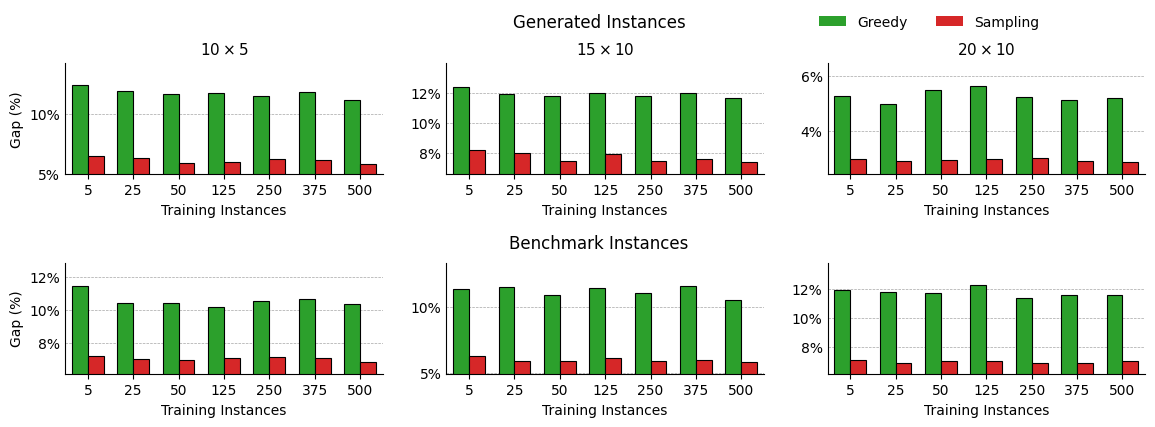

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as mpath
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


res_instance = [
        pd.read_csv("./results_dataset_size/instance_size/10_5.csv"),
        pd.read_csv("./results_dataset_size/instance_size/15_10.csv"),
        pd.read_csv("./results_dataset_size/instance_size/20_10.csv"),
    ]

x = np.arange(7)
bar_width = 0.35
bar_radius = 0.3
ylim_min, ylim_max = 0, 100
use_sd1_20_10 = False
color_greedy = 'tab:green'
color_samp = 'tab:red'
greedy_data = np.random.uniform(20, 80, (6, 4))
samp_data = np.random.uniform(10, 70, (6, 4))
# ax_titles = [f'Metric {i+1}' for i in range(6)]
ax_titles = [r"$10\times5$", r"$15\times10$",  r"$20\times10$"]
row_titles = ["Generated Instances", "Benchmark Instances"]

main_titles_font = 12
sub_titles_font = 11
labels_font = 10
ticks_font = 10
legend_font = 10


def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])


# Create a 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(12, 4.5))


# Plot bars

for i in range(3):
    ax_top = axes[0, i]
    ax_bottom = axes[1, i]
    gap_gen_greedy = res_instance[i]["gap_gen_greedy"].tolist()
    gap_gen_samp = res_instance[i]["gap_gen_samp"].tolist()
    gap_bench_greedy = res_instance[i]["gap_bench_greedy"].tolist()
    gap_bench_samp = res_instance[i]["gap_bench_samp"].tolist()
    max_greedy_gen = max(gap_gen_greedy)
    max_greedy_bench = max(gap_bench_greedy)
    min_samp_gen = min(gap_gen_samp)
    min_samp_bench = min(gap_bench_samp)

    ax_top.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    ax_bottom.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    x_ticks_name = res_instance[i]["exp_name"].tolist()
    x_ticks_name = [str(x) for x in x_ticks_name]
    x_ticks_name = x_ticks_name
    if i == 2:
        bar_radius_top = bar_radius / 1.75
        bar_radius_bottom = bar_radius
    else:
        bar_radius_top = bar_radius / 1.75
        bar_radius_bottom = bar_radius
    for j in range(7):
        base_color = color_greedy
        light_color = color_samp
        # print(gap_gen_greedy[j])
        ax_top.bar(x[j] - bar_width / 2, gap_gen_greedy[j], bar_width,
               color=base_color, edgecolor='black', linewidth=0.8, zorder=2)
        ax_top.bar(x[j] + bar_width / 2, gap_gen_samp[j], bar_width,
               color=light_color, edgecolor='black', linewidth=0.8, zorder=2)

        ax_bottom.bar(x[j] - bar_width / 2, gap_bench_greedy[j], bar_width,
               color=base_color, edgecolor='black', linewidth=0.8, zorder=2)
        ax_bottom.bar(x[j] + bar_width / 2, gap_bench_samp[j], bar_width,
               color=light_color, edgecolor='black', linewidth=0.8, zorder=2)

        # draw_top_rounded_bar(ax_top, x[j] - bar_width / 2, gap_gen_greedy[j], bar_width, base_color, bar_radius_top)
        # draw_top_rounded_bar(ax_top, x[j] + bar_width / 2, gap_gen_samp[j], bar_width, light_color, bar_radius_top)
        # draw_top_rounded_bar(ax_bottom, x[j] - bar_width / 2, gap_bench_greedy[j], bar_width, base_color, bar_radius_bottom)
        # draw_top_rounded_bar(ax_bottom, x[j] + bar_width / 2, gap_bench_samp[j], bar_width, light_color, bar_radius_bottom)
        ax_top.set_xlim(-0.5, 6.5)
        ax_top.set_ylim(min_samp_gen * 0.85, max_greedy_gen * 1.15)
        ax_top.set_xticks(np.arange(0, 7))
        ax_top.set_xticklabels(x_ticks_name, fontsize=ticks_font)
        ax_top.set_title(ax_titles[i], fontsize=sub_titles_font)

        ax_bottom.set_xlim(-0.5, 6.5)
        ax_bottom.set_ylim(min_samp_bench * 0.85, max_greedy_bench * 1.15)
        # ax_top.relim()
        # ax_top.autoscale_view()
        # ax_bottom.relim()
        # ax_bottom.autoscale_view()
        # ax_bottom.plt.xticks(ticks=x, labels=labels)
        ax_bottom.set_xticks(np.arange(0, 7))
        ax_bottom.set_xticklabels(x_ticks_name, fontsize=ticks_font)
        ax_bottom.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax_top.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
        ax_top.tick_params(labelsize=ticks_font)
        ax_bottom.tick_params(labelsize=ticks_font)

        ax_top.set_xlabel("Training Instances", fontsize=labels_font)

        ax_top.spines['right'].set_visible(False)
        ax_top.spines['top'].set_visible(False)
        ax_top.tick_params(axis='y', length=0)

        ax_bottom.spines['right'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)
        ax_bottom.tick_params(axis='y', length=0)
        ax_bottom.set_xlabel("Training Instances", fontsize=labels_font)


# Add y-axis label to leftmost subplots
axes[0, 0].set_ylabel("Gap (%)", fontsize=labels_font)
axes[1, 0].set_ylabel("Gap (%)", fontsize=labels_font)

# Add shared row titles centered above each row
fig.text(0.525, 0.89, row_titles[0], ha='center', va='center', fontsize=main_titles_font)
fig.text(0.525, 0.4, row_titles[1], ha='center', va='center', fontsize=main_titles_font)


# Custom legend
legend_elements = []
legend_elements.append(Patch(facecolor=color_greedy, label=f'Greedy'))
legend_elements.append(Patch(facecolor=color_samp, label=f'Sampling'))

fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=legend_font, frameon=False, bbox_to_anchor=(0.8, 0.935))

# Adjust layout
plt.subplots_adjust(wspace=0.2, hspace=0.8, left=0.08, right=0.98, top=0.8)
# plt.show()
plt.savefig('plot/figure_dataset_size.png', dpi=500, bbox_inches='tight', transparent=True)


In [9]:
df = pd.read_csv("./results_dataset_size/instance_size/10_5.csv")

In [10]:
df = pd.read_csv("./results_dataset_size/instance_size/15_10.csv")
df

,exp_name,gap_gen_greedy,gap_gen_greedy_std,gap_gen_samp,gap_gen_samp_std,gap_bench_greedy,gap_bench_greedy_std,gap_bench_samp,gap_bench_samp_std
0,5,13.034146,0.099831,7.678424,0.462936,11.375164,0.510695,6.225850,0.229627
1,25,12.414646,0.480672,7.435512,0.398903,11.487342,0.617895,5.858108,0.129537
2,50,12.253288,0.558599,6.826624,0.498904,10.913164,0.170312,5.917067,0.169285
3,125,12.472612,0.438601,7.407915,0.870805,11.455562,1.128488,6.084266,0.301886
4,250,12.223473,0.471980,6.786099,0.766171,11.078511,0.253428,5.850524,0.203153
5,375,12.493405,0.185487,6.982223,0.461875,11.616220,0.975247,5.987156,0.143602
6,500,12.040907,0.592660,6.697404,0.617766,10.515793,0.158362,5.781191,0.278909


In [11]:
df = pd.read_csv("./results_dataset_size/instance_size/20_10.csv")
df

,exp_name,gap_gen_greedy,gap_gen_greedy_std,gap_gen_samp,gap_gen_samp_std,gap_bench_greedy,gap_bench_greedy_std,gap_bench_samp,gap_bench_samp_std
0,5,5.290163,0.623174,2.983914,0.820697,12.370624,1.084913,6.449242,0.321772
1,25,4.992851,0.671548,2.904057,0.482996,12.230601,0.597375,6.174174,0.240281
2,50,5.486975,0.506279,2.963541,0.486606,12.124068,0.782384,6.296458,0.187271
3,125,5.629866,1.193038,2.986323,0.735020,12.812113,1.391606,6.286999,0.517380
4,250,5.247392,0.537820,3.038740,0.498619,11.749799,0.795270,6.189679,0.266164
5,375,5.118810,0.584306,2.904402,0.624785,11.954398,0.934783,6.158770,0.274601
6,500,5.200200,0.656205,2.870921,0.726693,11.982008,0.599435,6.294178,0.216034


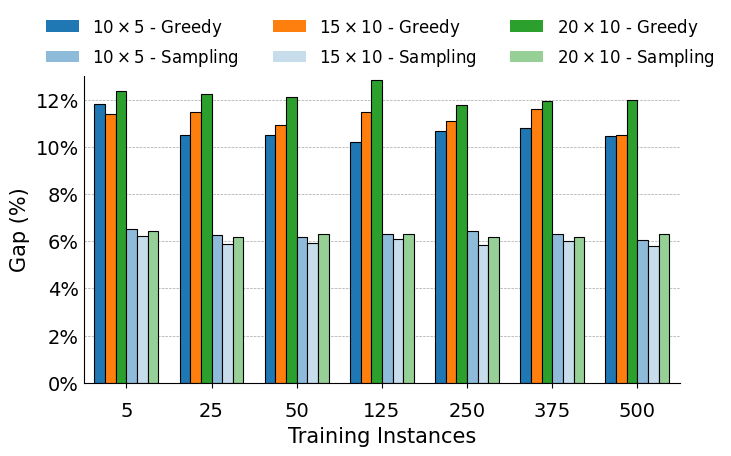

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Load benchmark data for different training sizes
res_instance = [
    pd.read_csv("./results_dataset_size/instance_size/10_5.csv"),
    pd.read_csv("./results_dataset_size/instance_size/15_10.csv"),
    pd.read_csv("./results_dataset_size/instance_size/20_10.csv"),
]

# Settings
x = np.arange(7)
bar_width = 0.125  # Smaller to fit 6 bars per group
color_list = ['tab:blue', 'tab:orange', 'tab:green']
instance_labels = [r"$10\times5$", r"$15\times10$", r"$20\times10$"]

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return [(1 - amount) * comp + amount for comp in c]

# Initialize plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7, zorder=1)

# Plot bars
bar_offsets = [-1.5, -1, 0, 0.5, 1.5, 2]  # 6 bars per x-tick
all_values = []

greedy_vals_10_5 = res_instance[0]["gap_bench_greedy"].tolist()
greedy_vals_15_10 = res_instance[1]["gap_bench_greedy"].tolist()
greedy_vals_20_10 = res_instance[2]["gap_bench_greedy"].tolist()
samp_vals_10_5 = res_instance[0]["gap_bench_samp"].tolist()
samp_vals_15_10 = res_instance[1]["gap_bench_samp"].tolist()
samp_vals_20_10 = res_instance[2]["gap_bench_samp"].tolist()
colour_greedy_10_5 = color_list[0]
colour_samp_10_5 = lighten_color(colour_greedy_10_5)
colour_greedy_15_10 = color_list[1]
colour_samp_15_10 = lighten_color(colour_samp_10_5)
colour_greedy_20_10 = color_list[2]
colour_samp_20_10 = lighten_color(colour_greedy_20_10)
greedy_10_5_pos = x + (0 - 6 / 2) * bar_width + bar_width / 2
greedy_15_10_pos = x + (1 - 6 / 2) * bar_width + bar_width / 2
greedy_20_10_pos = x + (2 - 6 / 2) * bar_width + bar_width / 2
samp_10_5_pos = x + (3 - 6 / 2) * bar_width + bar_width / 2
samp_15_10_pos = x + (4 - 6 / 2) * bar_width + bar_width / 2
samp_20_10_pos = x + (5 - 6 / 2) * bar_width + bar_width / 2



# Track legend handles
legend_elements = []
ax.bar(greedy_10_5_pos, greedy_vals_10_5, bar_width, color=colour_greedy_10_5, edgecolor='black', linewidth=0.8, zorder=2)

ax.bar(greedy_15_10_pos, greedy_vals_15_10, bar_width, color=colour_greedy_15_10, edgecolor='black', linewidth=0.8, zorder=2)
ax.bar(greedy_20_10_pos, greedy_vals_20_10, bar_width, color=colour_greedy_20_10, edgecolor='black', linewidth=0.8, zorder=2)
ax.bar(samp_10_5_pos, samp_vals_10_5, bar_width, color=colour_samp_10_5, edgecolor='black', linewidth=0.8, zorder=2)
ax.bar(samp_15_10_pos, samp_vals_15_10, bar_width, color=colour_samp_15_10, edgecolor='black', linewidth=0.8, zorder=2)
ax.bar(samp_20_10_pos, samp_vals_20_10, bar_width,
       color=colour_samp_20_10, edgecolor='black', linewidth=0.8, zorder=2)
legend_elements.append(Patch(facecolor=colour_greedy_10_5, label=r'$10 \times 5$ - Greedy'))
legend_elements.append(Patch(facecolor=colour_samp_10_5, label=r'$10 \times 5$ - Sampling'))
legend_elements.append(Patch(facecolor=colour_greedy_15_10, label=r'$15 \times 10$ - Greedy'))
legend_elements.append(Patch(facecolor=colour_samp_15_10, label=r'$15 \times 10$ - Sampling'))
legend_elements.append(Patch(facecolor=colour_greedy_20_10, label=r'$20 \times 10$ - Greedy'))
legend_elements.append(Patch(facecolor=colour_samp_20_10, label=r'$20 \times 10$ - Sampling'))
# for i in range(3):  # For each training size
#     df = res_instance[i]
#     greedy_vals = df["gap_bench_greedy"].tolist()
#     samp_vals = df["gap_bench_samp"].tolist()
#
#     base_color = color_list[i]
#     light_color = lighten_color(base_color)
#
#     greedy_offset = bar_offsets[i * 2]
#     samp_offset = bar_offsets[i * 2 + 1]
#
#     # Plot greedy
#     ax.bar(x + greedy_offset * bar_width, greedy_vals, bar_width,
#            color=base_color, edgecolor='black', linewidth=0.8, zorder=2)
#     # Plot sampling
#     ax.bar(x + samp_offset * bar_width, samp_vals, bar_width,
#            color=light_color, edgecolor='black', linewidth=0.8, zorder=2)
#
#     # Update value range
#     all_values.extend(greedy_vals + samp_vals)
#
#     # Add to legend (only once per label)
#     legend_elements.append(Patch(facecolor=base_color, label=f'{instance_labels[i]} - Greedy'))
#     legend_elements.append(Patch(facecolor=light_color, label=f'{instance_labels[i]} - Sampling'))

# Axis settings
ax.set_xlim(-0.5, 6.5)
ax.set_ylim(0, 13)
ax.set_xticks(np.arange(0, 7))
ax.set_xticklabels(res_instance[0]["exp_name"].tolist(), fontsize=12.5)
ax.tick_params(axis='x', pad=10)  # Increased spacing from axis
ax.set_ylabel("Gap (%)", fontsize=15)
ax.set_xlabel("Training Instances", fontsize=15)
# ax.set_title("Benchmark Instances", fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.tick_params(labelsize=14)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Legend
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=12, frameon=False, bbox_to_anchor=(0.55, 1.15))

# Final layout
plt.tight_layout()
plt.savefig('plot/benchmark_only_ordered.png', dpi=600, bbox_inches='tight', transparent=True)
# plt.show()


In [13]:
print(greedy_vals_10_5)

[11.796358579687611, 10.493890734182038, 10.50148803575894, 10.2051555074324, 10.666650969270725, 10.802266607618112, 10.452404163801404]


In [14]:
import scipy.stats as stats
import numpy as np


greedy_vals_10_5 = res_instance[0]["gap_bench_greedy"].tolist()
greedy_vals_15_10 = res_instance[1]["gap_bench_greedy"].tolist()
greedy_vals_20_10 = res_instance[2]["gap_bench_greedy"].tolist()
samp_vals_10_5 = res_instance[0]["gap_bench_samp"].tolist()
samp_vals_15_10 = res_instance[1]["gap_bench_samp"].tolist()
samp_vals_20_10 = res_instance[2]["gap_bench_samp"].tolist()

greedy_vals_10_5_std = res_instance[0]["gap_bench_greedy_std"].tolist()
greedy_vals_15_10_std = res_instance[1]["gap_bench_greedy_std"].tolist()
greedy_vals_20_10_std = res_instance[2]["gap_bench_greedy_std"].tolist()
samp_vals_10_5_std = res_instance[0]["gap_bench_samp_std"].tolist()
samp_vals_15_10_std = res_instance[1]["gap_bench_samp_std"].tolist()
samp_vals_20_10_std = res_instance[2]["gap_bench_samp_std"].tolist()
# Summary statistics for group 1
mean1 = greedy_vals_15_10[0]
std1 = greedy_vals_15_10_std[0]
n1 = 4

# Summary statistics for group 2
mean2 = greedy_vals_10_5[1]
std2 = greedy_vals_15_10_std[1]
n2 = 4
# Compute t statistic
se1 = std1**2 / n1
se2 = std2**2 / n2
se_diff = np.sqrt(se1 + se2)

t_statistic = (mean1 - mean2) / se_diff

# Degrees of freedom (Welch–Satterthwaite equation)
df = (se1 + se2)**2 / ((se1**2 / (n1 - 1)) + (se2**2 / (n2 - 1)))

# Two-tailed p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

print(f"T-statistic: {t_statistic:.4f}")
print(f"Degrees of freedom: {df:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 2.1987
Degrees of freedom: 5.79
P-value: 0.0718


In [6]:
import scipy.stats as stats
import numpy as np

# Summary statistics for group 1
mean1 = 11.59
std1 = 0.53
n1 = 4 * 100

# Summary statistics for group 2
mean2 = 11.19
std2 = 0.4
n2 = 4 * 100
# Compute t statistic
se1 = std1**2 / n1
se2 = std2**2 / n2
se_diff = np.sqrt(se1 + se2)

t_statistic = (mean1 - mean2) / se_diff

# Degrees of freedom (Welch–Satterthwaite equation)
df = (se1 + se2)**2 / ((se1**2 / (n1 - 1)) + (se2**2 / (n2 - 1)))

# Two-tailed p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

print(f"T-statistic: {t_statistic:.4f}")
print(f"Degrees of freedom: {df:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 12.0481
Degrees of freedom: 742.19
P-value: 0.0000
